In [1]:
# ============================================================
# Get Fit with Drishti
# Phase 5 Part D: Engagement Timing Rule
# Step 1: Create engagement timing base table
# ============================================================

# Import pandas for data analysis
import pandas as pd

# Import numpy for conditional logic
import numpy as np


# ------------------------------------------------------------
# 1. Load the cleaned dataset
# ------------------------------------------------------------

# Load cleaned data from the cleaned data folder
df = pd.read_csv("../02_cleaned_data/Drishti_Clean_Data.csv")

# Show dataset size
print("Dataset shape:")
print(df.shape)


# ------------------------------------------------------------
# 2. Check Days_To_First_Engagement values
# ------------------------------------------------------------

# Show original values and counts
print("\nOriginal Days_To_First_Engagement values:")
print(df["Days_To_First_Engagement"].value_counts(dropna=False).sort_index())


# ------------------------------------------------------------
# 3. Convert Days_To_First_Engagement into numeric format
# ------------------------------------------------------------

# Replace "Never" with 999 so it can be analyzed numerically
df["Days_To_First_Engagement_Num"] = df["Days_To_First_Engagement"].replace("Never", 999)

# Convert the column to numeric
df["Days_To_First_Engagement_Num"] = pd.to_numeric(
    df["Days_To_First_Engagement_Num"],
    errors="coerce"
)

# Check the converted values
print("\nConverted Days_To_First_Engagement values:")
print(df["Days_To_First_Engagement_Num"].value_counts(dropna=False).sort_index())


# ------------------------------------------------------------
# 4. Create outcome flags for business analysis
# ------------------------------------------------------------

# Completion flag:
# 1 = Completed
# 0 = Ghost, Inactive, Quit, or other non-completed statuses
df["Completed_Flag"] = np.where(
    df["Status"] == "Completed",
    1,
    0
)

# Churn flag:
# 1 = Ghost, Inactive, or Quit
# 0 = Completed
df["Churned_Flag"] = np.where(
    df["Status"].isin(["Ghost", "Inactive", "Quit"]),
    1,
    0
)

# Goal achievement flag:
# 1 = Yes or Partial
# 0 = No or Ongoing
df["Goal_Achieved_Flag"] = np.where(
    df["Goal_Achieved"].isin(["Yes", "Partial"]),
    1,
    0
)


# ------------------------------------------------------------
# 5. Create engagement analysis table
# ------------------------------------------------------------

# Keep only columns needed for Part D
engagement_df = df[
    [
        "Client_ID",
        "Status",
        "Days_To_First_Engagement",
        "Days_To_First_Engagement_Num",
        "Completed_Flag",
        "Churned_Flag",
        "Checkin_Rate_Pct",
        "Goal_Achieved",
        "Goal_Achieved_Flag"
    ]
].copy()

# Preview the analysis table
print("\nEngagement analysis table preview:")
engagement_df.head(10)

Dataset shape:
(3000, 40)

Original Days_To_First_Engagement values:
Days_To_First_Engagement
0      937
1      585
2      449
3      461
5      289
7      146
999    133
Name: count, dtype: int64

Converted Days_To_First_Engagement values:
Days_To_First_Engagement_Num
0      937
1      585
2      449
3      461
5      289
7      146
999    133
Name: count, dtype: int64

Engagement analysis table preview:


,Client_ID,Status,Days_To_First_Engagement,Days_To_First_Engagement_Num,Completed_Flag,Churned_Flag,Checkin_Rate_Pct,Goal_Achieved,Goal_Achieved_Flag
0,C0001,Completed,3,3,1,0,100.0,Partial,1
1,C0002,Ghost,999,999,0,1,7.1,No,0
2,C0003,Completed,3,3,1,0,78.6,Partial,1
3,C0004,Completed,5,5,1,0,100.0,Yes,1
4,C0005,Ghost,0,0,0,1,0.0,No,0
5,C0006,Completed,1,1,1,0,100.0,Partial,1
6,C0007,Ghost,5,5,0,1,7.1,No,0
7,C0008,Completed,2,2,1,0,78.6,Yes,1
8,C0009,Completed,0,0,1,0,85.7,Partial,1
9,C0010,Inactive,0,0,0,1,14.3,Ongoing,0


Engagement timing outcome summary:
  Engagement_Label  Days_To_First_Engagement_Num  Client_Count  \
0                0                             0           937   
1                1                             1           585   
2                2                             2           449   
3                3                             3           461   
4                5                             5           289   
5                7                             7           146   
6            Never                           999           133   

   Completion_Rate_Pct  Churn_Rate_Pct  Avg_Checkin_Rate_Pct  \
0                89.43           10.57                 81.36   
1                88.55           11.45                 80.89   
2                87.97           12.03                 80.19   
3                87.20           12.80                 80.22   
4                64.71           35.29                 64.07   
5                62.33           37.67              

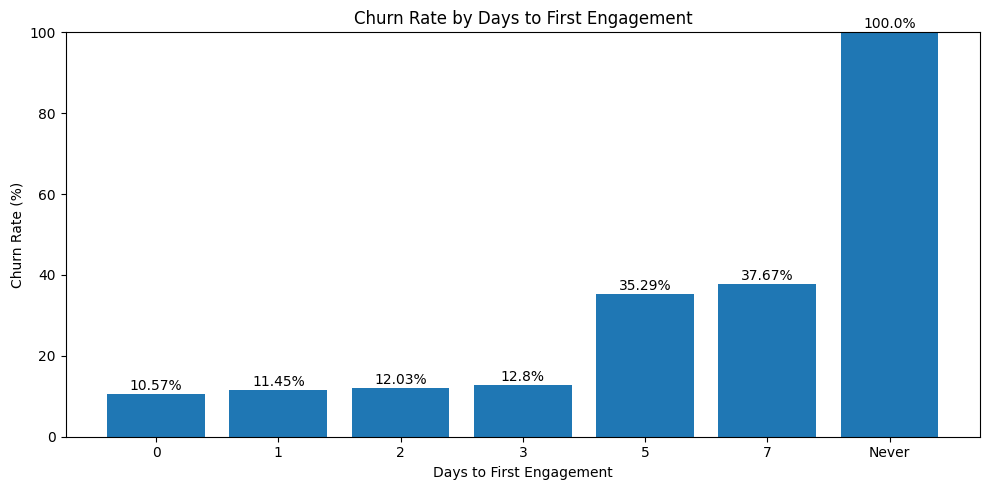

In [2]:
# ============================================================
# Phase 5 Part D
# Step 2: Analyze outcomes by first engagement timing
# ============================================================

# ------------------------------------------------------------
# 1. Create outcome summary by first engagement day
# ------------------------------------------------------------

# Group clients by Days_To_First_Engagement_Num and calculate key outcomes
engagement_timing_summary = (
    engagement_df
    .groupby("Days_To_First_Engagement_Num")
    .agg(
        Client_Count=("Client_ID", "count"),
        Completion_Rate_Pct=("Completed_Flag", lambda x: x.mean() * 100),
        Churn_Rate_Pct=("Churned_Flag", lambda x: x.mean() * 100),
        Avg_Checkin_Rate_Pct=("Checkin_Rate_Pct", "mean"),
        Goal_Achievement_Rate_Pct=("Goal_Achieved_Flag", lambda x: x.mean() * 100)
    )
    .reset_index()
)

# Round all numeric results for clean display
engagement_timing_summary[
    [
        "Completion_Rate_Pct",
        "Churn_Rate_Pct",
        "Avg_Checkin_Rate_Pct",
        "Goal_Achievement_Rate_Pct"
    ]
] = engagement_timing_summary[
    [
        "Completion_Rate_Pct",
        "Churn_Rate_Pct",
        "Avg_Checkin_Rate_Pct",
        "Goal_Achievement_Rate_Pct"
    ]
].round(2)

# Replace 999 label with "Never" for easier reading
engagement_timing_summary["Engagement_Label"] = engagement_timing_summary[
    "Days_To_First_Engagement_Num"
].replace({999: "Never"})

# Reorder columns
engagement_timing_summary = engagement_timing_summary[
    [
        "Engagement_Label",
        "Days_To_First_Engagement_Num",
        "Client_Count",
        "Completion_Rate_Pct",
        "Churn_Rate_Pct",
        "Avg_Checkin_Rate_Pct",
        "Goal_Achievement_Rate_Pct"
    ]
]

print("Engagement timing outcome summary:")
print(engagement_timing_summary)


# ------------------------------------------------------------
# 2. Create a simple chart for churn rate by engagement timing
# ------------------------------------------------------------

# Import matplotlib for charting
import matplotlib.pyplot as plt

# Create chart canvas
plt.figure(figsize=(10, 5))

# Create bar chart
plt.bar(
    engagement_timing_summary["Engagement_Label"].astype(str),
    engagement_timing_summary["Churn_Rate_Pct"]
)

# Add title and axis labels
plt.title("Churn Rate by Days to First Engagement")
plt.xlabel("Days to First Engagement")
plt.ylabel("Churn Rate (%)")

# Add labels on bars
for index, value in enumerate(engagement_timing_summary["Churn_Rate_Pct"]):
    plt.text(index, value + 1, str(value) + "%", ha="center")

# Keep y-axis from 0 to 100
plt.ylim(0, 100)

# Make layout clean
plt.tight_layout()

# Show chart
plt.show()

In [3]:
# ============================================================
# Phase 5 Part D
# Step 3: Calculate engagement threshold rule
# ============================================================

# ------------------------------------------------------------
# 1. Create threshold groups
# ------------------------------------------------------------

# Clients who engaged within 3 days are considered early engaged
# Clients who took more than 3 days, including 5, 7, and 999/Never, are delayed/no engagement
engagement_df["Engagement_Threshold_Group"] = np.where(
    engagement_df["Days_To_First_Engagement_Num"] <= 3,
    "Engaged Within 3 Days",
    "Did Not Engage Within 3 Days"
)


# ------------------------------------------------------------
# 2. Calculate outcomes by threshold group
# ------------------------------------------------------------

threshold_summary = (
    engagement_df
    .groupby("Engagement_Threshold_Group")
    .agg(
        Client_Count=("Client_ID", "count"),
        Completion_Rate_Pct=("Completed_Flag", lambda x: x.mean() * 100),
        Churn_Rate_Pct=("Churned_Flag", lambda x: x.mean() * 100),
        Avg_Checkin_Rate_Pct=("Checkin_Rate_Pct", "mean"),
        Goal_Achievement_Rate_Pct=("Goal_Achieved_Flag", lambda x: x.mean() * 100)
    )
    .reset_index()
)

# Round numeric values
threshold_summary[
    [
        "Completion_Rate_Pct",
        "Churn_Rate_Pct",
        "Avg_Checkin_Rate_Pct",
        "Goal_Achievement_Rate_Pct"
    ]
] = threshold_summary[
    [
        "Completion_Rate_Pct",
        "Churn_Rate_Pct",
        "Avg_Checkin_Rate_Pct",
        "Goal_Achievement_Rate_Pct"
    ]
].round(2)

print("Engagement threshold summary:")
print(threshold_summary)


# ------------------------------------------------------------
# 3. Calculate how much more likely delayed clients are to churn
# ------------------------------------------------------------

# Get churn rate for early-engaged clients
early_churn_rate = threshold_summary.loc[
    threshold_summary["Engagement_Threshold_Group"] == "Engaged Within 3 Days",
    "Churn_Rate_Pct"
].values[0]

# Get churn rate for delayed/no-engagement clients
delayed_churn_rate = threshold_summary.loc[
    threshold_summary["Engagement_Threshold_Group"] == "Did Not Engage Within 3 Days",
    "Churn_Rate_Pct"
].values[0]

# Absolute percentage-point increase
churn_rate_gap_points = delayed_churn_rate - early_churn_rate

# Relative increase:
# Example: if early churn is 11% and delayed churn is 45%,
# delayed clients are about 309% more likely to churn
relative_churn_increase_pct = (
    (delayed_churn_rate - early_churn_rate) / early_churn_rate * 100
)

print("\nThreshold rule calculation:")
print("Early engagement churn rate:", round(early_churn_rate, 2), "%")
print("Delayed/no engagement churn rate:", round(delayed_churn_rate, 2), "%")
print("Churn rate gap:", round(churn_rate_gap_points, 2), "percentage points")
print("Delayed/no-engagement clients are", round(relative_churn_increase_pct, 2), "% more likely to drop out.")


# ------------------------------------------------------------
# 4. Create simple business rule text
# ------------------------------------------------------------

engagement_rule = (
    f"If a new client has not engaged within 3 days, they are "
    f"{round(relative_churn_increase_pct, 2)}% more likely to drop out than clients who engage within 3 days."
)

print("\nEngagement Timing Rule:")
print(engagement_rule)

Engagement threshold summary:
     Engagement_Threshold_Group  Client_Count  Completion_Rate_Pct  \
0  Did Not Engage Within 3 Days           568                48.94   
1         Engaged Within 3 Days          2432                88.53   

   Churn_Rate_Pct  Avg_Checkin_Rate_Pct  Goal_Achievement_Rate_Pct  
0           51.06                 49.69                      48.94  
1           11.47                 80.81                      88.53  

Threshold rule calculation:
Early engagement churn rate: 11.47 %
Delayed/no engagement churn rate: 51.06 %
Churn rate gap: 39.59 percentage points
Delayed/no-engagement clients are 345.16 % more likely to drop out.

Engagement Timing Rule:
If a new client has not engaged within 3 days, they are 345.16% more likely to drop out than clients who engage within 3 days.


In [4]:
# ============================================================
# Phase 5 Part D
# Step 4: Create engagement timing action rule table
# ============================================================

# ------------------------------------------------------------
# 1. Build simple action rule table
# ------------------------------------------------------------

engagement_action_rules = pd.DataFrame({
    "Client Situation": [
        "Engaged on Day 0–1",
        "Engaged on Day 2–3",
        "No engagement by Day 3",
        "No engagement by Day 5",
        "Never engaged / fully silent"
    ],
    "Risk Level": [
        "Low",
        "Low to Medium",
        "High",
        "Very High",
        "Critical"
    ],
    "Why It Matters": [
        "Client is active early and likely to stay on track.",
        "Client is still inside the safe engagement window.",
        "This is the intervention deadline because churn risk rises sharply after Day 3.",
        "This group already shows much higher churn and lower goal achievement.",
        "Never-engaged clients had 100% churn in the dataset."
    ],
    "Recommended Action": [
        "Continue normal encouragement and reinforce the first small win.",
        "Send a light reminder and make the first check-in feel easy.",
        "Send a personal accountability message, ask what is blocking them, and offer a simple 10-minute restart task.",
        "Send a stronger reset message with social proof, progress examples, and a quick call/check-in option.",
        "Send one final supportive message, ask if they want to pause or restart, and mark them for win-back follow-up."
    ],
    "Example Message": [
        "Amazing start — keep this momentum going. Send me one quick update today so I can guide you better.",
        "Just checking in — send me one small update today, even if it is not perfect. We will adjust from there.",
        "Hey, I noticed you have not checked in yet. No pressure, but I do not want you to feel stuck alone. What is the main thing blocking you right now? Reply with just one word: time, food, workout, or motivation.",
        "I know starting can feel hard, but you do not need a perfect restart. I can give you a simple 10-minute plan for today. Also, I want to show you how another client restarted after struggling and still made progress.",
        "I have not heard from you, so I will pause active follow-up for now. If you want to restart, reply with RESET and I will help you begin again with one small step."
    ]
})

# Show the action rule table
print("Engagement Timing Action Rule Table:")
engagement_action_rules

Engagement Timing Action Rule Table:


,Client Situation,Risk Level,Why It Matters,Recommended Action,Example Message
0,Engaged on Day 0–1,Low,Client is active early and likely to stay on t...,Continue normal encouragement and reinforce th...,Amazing start — keep this momentum going. Send...
1,Engaged on Day 2–3,Low to Medium,Client is still inside the safe engagement win...,Send a light reminder and make the first check...,Just checking in — send me one small update to...
2,No engagement by Day 3,High,This is the intervention deadline because chur...,"Send a personal accountability message, ask wh...","Hey, I noticed you have not checked in yet. No..."
3,No engagement by Day 5,Very High,This group already shows much higher churn and...,Send a stronger reset message with social proo...,"I know starting can feel hard, but you do not ..."
4,Never engaged / fully silent,Critical,Never-engaged clients had 100% churn in the da...,"Send one final supportive message, ask if they...","I have not heard from you, so I will pause act..."


In [6]:
# ============================================================
# Phase 5 Part D
# Step 5: Save Engagement Timing Rule output files
# ============================================================

# Import os to create folders and save files
import os

# ------------------------------------------------------------
# 1. Create output folder for Phase 5 Part D
# ------------------------------------------------------------

# Set output folder path
output_folder = "../05_outputs/phase5_engagement_timing_rule"

# Create the folder if it does not already exist
os.makedirs(output_folder, exist_ok=True)

print("Output folder ready:")
print(output_folder)


# ------------------------------------------------------------
# 2. Save engagement timing summary from Step 2
# ------------------------------------------------------------

engagement_timing_summary.to_csv(
    f"{output_folder}/engagement_timing_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 3. Save engagement threshold summary from Step 3
# ------------------------------------------------------------

threshold_summary.to_csv(
    f"{output_folder}/engagement_threshold_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Save action rule table from Step 4
# ------------------------------------------------------------

engagement_action_rules.to_csv(
    f"{output_folder}/engagement_action_rules.csv",
    index=False
)


# ------------------------------------------------------------
# 5. Save client-level engagement analysis table
# ------------------------------------------------------------

engagement_df.to_csv(
    f"{output_folder}/engagement_analysis_client_table.csv",
    index=False
)


# ------------------------------------------------------------
# 6. Confirm saved files
# ------------------------------------------------------------

print("\nPhase 5 Part D files saved successfully.")
print("Saved folder:", output_folder)

print("\nSaved files:")
print("- engagement_timing_summary.csv")
print("- engagement_threshold_summary.csv")
print("- engagement_action_rules.csv")
print("- engagement_analysis_client_table.csv")

Output folder ready:
../05_outputs/phase5_engagement_timing_rule

Phase 5 Part D files saved successfully.
Saved folder: ../05_outputs/phase5_engagement_timing_rule

Saved files:
- engagement_timing_summary.csv
- engagement_threshold_summary.csv
- engagement_action_rules.csv
- engagement_analysis_client_table.csv
